# 🔧 Data Preprocessing (المعالجة المسبقة للبيانات)
**Day 2 — Data is Everything**

---

Raw data is almost never ready for a Machine Learning (التعلم الآلي) model. In this notebook, you'll learn the three essential preprocessing steps:

1. **Handling missing values** — what to do when data is incomplete
2. **Encoding categorical features** — converting text labels to numbers
3. **Feature scaling** — putting features on the same numerical scale

We'll continue with the Titanic dataset from the EDA notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

import warnings; warnings.filterwarnings("ignore")

# Reload dataset
try:
    df = sns.load_dataset("titanic")
except:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]

# Keep only the columns we'll work with
cols = ["survived", "pclass", "sex", "age", "fare", "embarked"]
df = df[cols].copy()
print("Starting shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Starting shape: (891, 6)

Missing values:
survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
dtype: int64


## 1. Handling Missing Values

You have three main options when a column has missing values:

| Strategy | When to use |
|---|---|
| **Drop rows** | Few missing, random distribution |
| **Drop column** | More than ~40% missing |
| **Impute** (fill in) | Missing is predictable from other data |

The *imputer* fills missing values with a summary statistic:
- **Median** for numerical columns (robust to outliers)
- **Most frequent** (mode) for categorical columns

In [3]:
# Show the problem first
print("BEFORE imputation:")
print(f"  age: {df['age'].isnull().sum()} missing values")
print(f"  embarked: {df['embarked'].isnull().sum()} missing values")
print(f"  Total rows before dropping: {len(df)}")

# Strategy 1: Drop rows where a critical feature is missing (only 2 rows for embarked)
df = df.dropna(subset=["embarked"])
print(f"\nAfter dropping rows with missing 'embarked': {len(df)} rows")

# Strategy 2: Median imputation for 'age' (age is roughly symmetric, median ≈ mean)
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age)

print(f"\nAFTER imputation:")
print(f"  Filled missing 'age' with median: {median_age:.0f}")
print(f"  Missing values remaining: {df.isnull().sum().sum()}")

BEFORE imputation:
  age: 177 missing values
  embarked: 2 missing values
  Total rows before dropping: 891

After dropping rows with missing 'embarked': 889 rows

AFTER imputation:
  Filled missing 'age' with median: 28
  Missing values remaining: 0


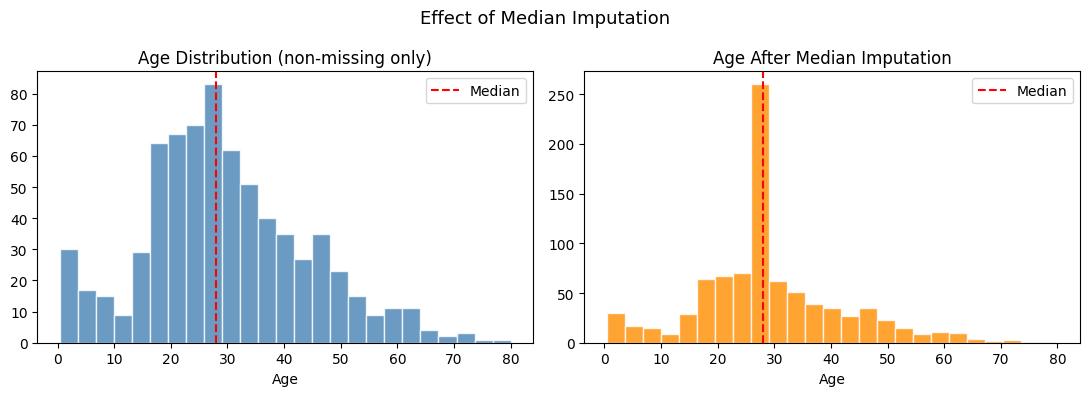

The shape is preserved. The median spike is visible — this is acceptable for a simple fill.


In [4]:
# Visualize: original distribution vs after imputation
# Simulate what the distribution looks like with vs without imputation
try:
    df_original = sns.load_dataset("titanic")[["age"]].copy()
except:
    df_original = df[["age"]].copy()
    df_original.loc[:150, "age"] = np.nan  # simulate missing

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_original["age"].dropna(), bins=25, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(df_original["age"].median(), color="red", linestyle="--", label="Median")
axes[0].set_title("Age Distribution (non-missing only)", fontsize=12)
axes[0].set_xlabel("Age"); axes[0].legend()

axes[1].hist(df["age"], bins=25, color="darkorange", edgecolor="white", alpha=0.8)
axes[1].axvline(df["age"].median(), color="red", linestyle="--", label="Median")
axes[1].set_title("Age After Median Imputation", fontsize=12)
axes[1].set_xlabel("Age"); axes[1].legend()

plt.suptitle("Effect of Median Imputation", fontsize=13)
plt.tight_layout(); plt.show()
print("The shape is preserved. The median spike is visible — this is acceptable for a simple fill.")

## 2. Encoding Categorical Variables

Machine Learning (التعلم الآلي) models are mathematical — they work with numbers, not words.

Any column with text categories must be converted to numbers. There are two main approaches:

**Label Encoding**: Assign each category an integer (0, 1, 2, ...).
- Use when: the categories have a natural order (e.g., Small < Medium < Large)

**One-Hot Encoding**: Create a new binary column for each category.
- Use when: categories have NO natural order (e.g., Male/Female, colors)

In [5]:
print("Before encoding:")
print("sex unique values:", df["sex"].unique())
print("embarked unique values:", df["embarked"].unique())
print()

# Label Encoding for 'sex' (binary — 2 options, no ordering issue)
le = LabelEncoder()
df["sex_encoded"] = le.fit_transform(df["sex"])
print("sex → sex_encoded mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print()

# One-Hot Encoding for 'embarked' (3 ports — no natural order)
# drop_first=True removes one column to avoid redundancy:
# if port_C=0 AND port_Q=0, we already know it must be Southampton (S)
df_encoded = pd.get_dummies(df, columns=["embarked"], prefix="port", drop_first=True)
print("New columns after one-hot encoding 'embarked':")
new_cols = [c for c in df_encoded.columns if c.startswith("port")]
print(" ", new_cols)
print("  ('S' is the baseline — encoded as all zeros)")
print()
print("First 3 rows of the encoded port columns:")
print(df_encoded[new_cols].head(3))

Before encoding:
sex unique values: <StringArray>
['male', 'female']
Length: 2, dtype: str
embarked unique values: <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

sex → sex_encoded mapping: {'female': np.int64(0), 'male': np.int64(1)}

New columns after one-hot encoding 'embarked':
  ['port_C', 'port_Q', 'port_S']

First 3 rows of the encoded port columns:
   port_C  port_Q  port_S
0   False   False    True
1    True   False   False
2   False   False    True


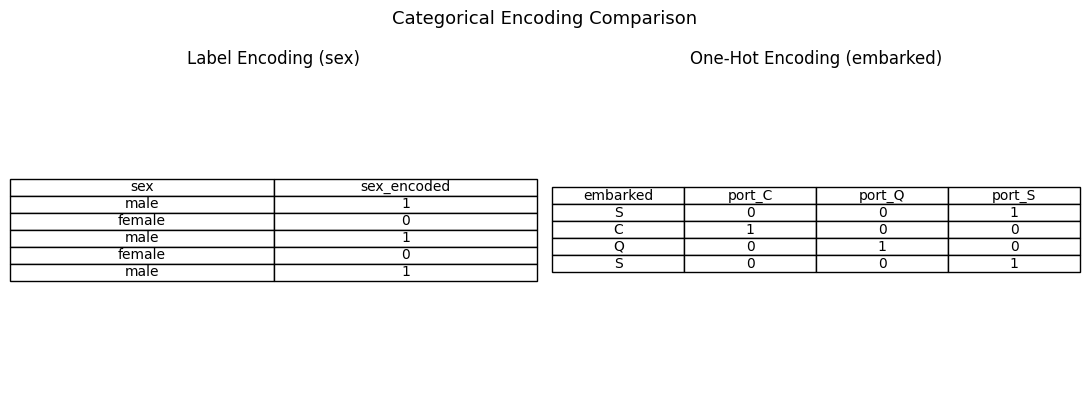

In [6]:
# Visualize encoding
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Label encoding: before and after
le_demo = pd.DataFrame({"sex": ["male", "female", "male", "female", "male"],
                         "sex_encoded": [1, 0, 1, 0, 1]})
axes[0].table(cellText=le_demo.values, colLabels=le_demo.columns,
              loc="center", cellLoc="center")
axes[0].axis("off")
axes[0].set_title("Label Encoding (sex)", fontsize=12)

# One-hot with drop_first: S is the baseline (both columns = 0)
ohe_demo = pd.DataFrame({
    "embarked": ["S",  "C",  "Q",  "S"],
    "port_C":   ["0",  "1",  "0",  "0"],
    "port_Q":   ["0",  "0",  "1",  "0"],
})
axes[1].table(cellText=ohe_demo.values, colLabels=ohe_demo.columns,
              loc="center", cellLoc="center")
axes[1].axis("off")
axes[1].set_title("One-Hot Encoding (embarked)\n'S' = baseline [0, 0]", fontsize=12)

plt.suptitle("Categorical Encoding Comparison", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Feature Scaling

Many ML algorithms are *sensitive to the scale of features*. Consider `age` (range: 1–80) vs. `fare` (range: 0–512). Without scaling, the algorithm might treat `fare` as more important simply because its numbers are bigger — even if `age` is actually more predictive.

**StandardScaler** transforms features to have mean=0 and std=1:
$$x_{scaled} = \frac{x - \mu}{\sigma}$$

**MinMaxScaler** transforms features to the range [0, 1]:
$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

In [7]:
print("BEFORE scaling:")
print(f"  age  — min: {df['age'].min():.0f}, max: {df['age'].max():.0f}, mean: {df['age'].mean():.1f}")
print(f"  fare — min: {df['fare'].min():.1f}, max: {df['fare'].max():.1f}, mean: {df['fare'].mean():.1f}")

# Fit ONE scaler on both columns at once — this is the correct pattern.
# (Here we fit on the full dataset for illustration.
#  In production, always fit ONLY on training data — covered in notebook 3.)
scaler = StandardScaler()
df[["age_scaled", "fare_scaled"]] = scaler.fit_transform(df[["age", "fare"]])

print("\nAFTER StandardScaler:")
print(f"  age_scaled  — min: {df['age_scaled'].min():.2f}, max: {df['age_scaled'].max():.2f}, mean: {df['age_scaled'].mean():.3f}")
print(f"  fare_scaled — min: {df['fare_scaled'].min():.2f}, max: {df['fare_scaled'].max():.2f}, mean: {df['fare_scaled'].mean():.3f}")

BEFORE scaling:
  age  — min: 0, max: 80, mean: 29.3
  fare — min: 0.0, max: 512.3, mean: 32.1

AFTER StandardScaler:
  age_scaled  — min: -2.23, max: 3.91, mean: 0.000
  fare_scaled — min: -0.65, max: 9.67, mean: 0.000


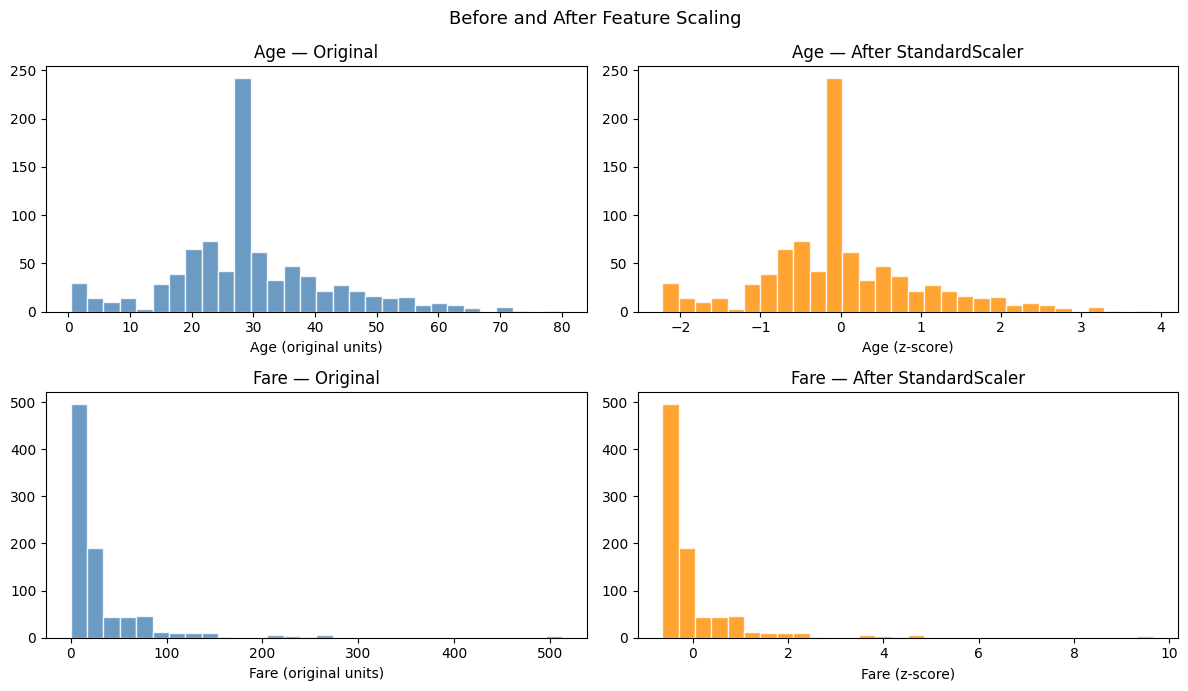

The SHAPE of each distribution is identical — scaling just changes the units, not the data.


In [8]:
# Visualize scaling effect
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for i, (col, col_s, label) in enumerate([("age", "age_scaled", "Age"),
                                           ("fare", "fare_scaled", "Fare")]):
    axes[i, 0].hist(df[col],   bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i, 0].set_title(f"{label} — Original",  fontsize=12)
    axes[i, 0].set_xlabel(f"{label} (original units)")

    axes[i, 1].hist(df[col_s], bins=30, color="darkorange", edgecolor="white", alpha=0.8)
    axes[i, 1].set_title(f"{label} — After StandardScaler", fontsize=12)
    axes[i, 1].set_xlabel(f"{label} (z-score)")

plt.suptitle("Before and After Feature Scaling", fontsize=13)
plt.tight_layout(); plt.show()
print("The SHAPE of each distribution is identical — scaling just changes the units, not the data.")

## Putting It All Together: The Preprocessing Pipeline

In practice, you'll apply all three steps in sequence. Scikit-learn's `Pipeline` makes this clean and reproducible.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define our feature columns
numeric_features     = ["age", "fare", "pclass"]
categorical_features = ["sex", "embarked"]
target               = "survived"

# Drop rows where embarked is still missing (safety)
df_clean = df[numeric_features + categorical_features + [target]].dropna().copy()

X = df_clean[numeric_features + categorical_features]
y = df_clean[target]

# Build a preprocessing pipeline
numeric_transformer     = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                                           ("scaler",  StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                           ("onehot",  OneHotEncoder(drop="first", sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[
    ("num",  numeric_transformer,     numeric_features),
    ("cat",  categorical_transformer, categorical_features),
])

X_processed = preprocessor.fit_transform(X)
print(f"Original shape:   {X.shape}")
print(f"Processed shape:  {X_processed.shape}")
print()
print("The pipeline handled imputation, encoding, and scaling in one step.")
print("This processed data is ready to feed directly into any ML model.")

Original shape:   (889, 5)
Processed shape:  (889, 6)

The pipeline handled imputation, encoding, and scaling in one step.
This processed data is ready to feed directly into any ML model.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# The payoff question: does all this preprocessing actually help?
# Compare the same model type on raw vs. preprocessed data.

# Baseline: reload original (missing values present), numeric features only, drop incomplete rows
try:
    df_orig = sns.load_dataset("titanic")[["survived", "pclass", "age", "fare"]].dropna()
except:
    df_orig = df_clean[["survived", "pclass", "age", "fare"]].copy()

X_raw = df_orig[["pclass", "age", "fare"]].values
y_raw = df_orig["survived"].values
model_raw = LogisticRegression(max_iter=500, random_state=42)
model_raw.fit(X_raw, y_raw)
acc_raw = accuracy_score(y_raw, model_raw.predict(X_raw))

# Preprocessed: 5 features, imputed + encoded + scaled via our pipeline
model_proc = LogisticRegression(max_iter=500, random_state=42)
model_proc.fit(X_processed, y)
acc_proc = accuracy_score(y, model_proc.predict(X_processed))

print(f"Without preprocessing — {len(X_raw):>3} rows, 3 numeric features   — accuracy: {acc_raw:.1%}")
print(f"With preprocessing    — {len(X_processed):>3} rows, {X_processed.shape[1]} features (enc+scaled) — accuracy: {acc_proc:.1%}")
print()
print("Preprocessing gains come from:")
print("  Encoding  → unlocks 'sex' and 'embarked', which are the two strongest predictors")
print("  Imputing  → recovers rows dropped for missing age (more data = better model)")
print("  Scaling   → ensures 'fare' (0–512) doesn't overwhelm 'pclass' (1–3)")

---

## ✋ Exercise — Preprocess a New Dataset

In [10]:
# Load the diamonds dataset
try:
    diamonds = sns.load_dataset("diamonds").sample(500, random_state=42)
except:
    np.random.seed(42)
    n = 500
    diamonds = pd.DataFrame({
        "carat": np.random.lognormal(-0.3, 0.5, n).round(2),
        "cut":   np.random.choice(["Fair","Good","Very Good","Premium","Ideal"], n),
        "color": np.random.choice(list("DEFGHIJ"), n),
        "depth": np.random.normal(61.7, 1.4, n).round(1),
        "price": (np.random.lognormal(7.2, 0.7, n)).astype(int),
    })

print("Diamonds dataset shape:", diamonds.shape)
print(diamonds.head())
print()
print("Task: Preprocess this dataset so it's ready for ML")
print("  - 'price' is our target (y)")
print("  - All other columns are features (X)")

Diamonds dataset shape: (500, 10)
       carat        cut color clarity  depth  table  price     x     y     z
1388    0.24      Ideal     G    VVS1   62.1   56.0    559  3.97  4.00  2.47
50052   0.58  Very Good     F    VVS2   60.0   57.0   2201  5.44  5.42  3.26
41645   0.40      Ideal     E    VVS2   62.1   55.0   1238  4.76  4.74  2.95
42377   0.43    Premium     E    VVS2   60.8   57.0   1304  4.92  4.89  2.98
17244   1.55      Ideal     E     SI2   62.3   55.0   6901  7.44  7.37  4.61

Task: Preprocess this dataset so it's ready for ML
  - 'price' is our target (y)
  - All other columns are features (X)


In [11]:
# ── WORKED EXAMPLE ──────────────────────────────────────────────────────────
# Here is a complete Task 1 solution so you can see the pattern:
print("Worked example — missing value check:")
print(diamonds.isnull().sum())
print("(Diamonds dataset has no missing values — good news!)")
print()

# ── YOUR TURN ─────────────────────────────────────────────────────────────────

# TASK 1: What are the unique values in 'cut'? Are they ordered (Small→Large) or unordered?
# Decide: would label encoding or one-hot encoding be more appropriate?
# Hint: diamonds["cut"].unique()  and  diamonds["cut"].value_counts()
# YOUR CODE HERE:


# TASK 2: Encode 'cut' and 'color' using pd.get_dummies(drop_first=True)
# Store the result as  diamonds_enc
# Then print the new column names to confirm encoding worked
# YOUR CODE HERE:


# TASK 3: Scale the numeric columns ['carat', 'depth'] using StandardScaler
# Fit the scaler and print the mean of each column before and after scaling
# YOUR CODE HERE:


# TASK 4: Separate into X (all features except 'price') and y ('price')
# Print the final shape of X
# YOUR CODE HERE:

print("\nWhen done: X should be all numbers and y should be the price column.")

When done: X should be all numbers, all scaled.
